# Round 3 Initial Product Analysis

Exploratory analysis for Round 3's three product families:
- `VELVETFRUIT_EXTRACT` — tradable good that is also the **option underlying**.
- `HYDROGEL_PACK` — second tradable good (candidate stationary MM product).
- `VEV_<K>` vouchers at 10 strikes (European-style call options on `VELVETFRUIT_EXTRACT`).

Goals:
1. Load and combine all price / trade files across days 0, 1, 2.
2. Build per-product wall-price features.
3. Characterise spot products (stationarity / drift / trend regime).
4. Estimate realized vol of the underlying for option pricing.
5. Build three voucher fair-value models (no-arb, flat BSM, per-timestamp smile parabola).
6. Construct a smile-detrended deviation signal as a candidate scalping strategy.
7. Inspect flow / trader patterns (buyer-seller fields are empty → no named-trader signal).
8. Cross-strike arbitrage checks.
9. Initial strategy ideas and open questions.

Notebook style: every code cell is preceded by a markdown block describing Purpose / Expected / Intuition / Steps, mirroring `../Round_1/round1_initial_analysis.ipynb`. Plots use `seaborn` with a shared theme and a fixed colour per strike so the 10 vouchers are comparable throughout.


### Purpose
- Load all three days of Round 3 data and confirm product list.
- Install a single plotting theme and a strike→colour map reused everywhere.
- Define the small helper functions that the rest of the notebook will call.

### Expected Result
- One combined `prices` DataFrame and one `trades` DataFrame.
- A summary table showing row counts per day and assumed TTE per day.

### Intuition
- Defining helpers once at the top keeps later cells short and easy to scan.
- A fixed strike palette means the same colour = same strike across every figure.

### Steps
1. Imports + global seaborn theme + notebook constants.
2. Data directory resolver that works from both repo root and `Round_3/`.
3. Load and concatenate prices/trades across days 0, 1, 2.
4. Define vectorised BSM, implied vol, smile-fit, and plotting helpers.


In [66]:
from __future__ import annotations

from pathlib import Path
from typing import Callable, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from IPython.display import Markdown, display

sns.set_theme(context="notebook", style="whitegrid", palette="rocket_r")
plt.rcParams["figure.figsize"]    = (12, 5)
plt.rcParams["axes.titleweight"]  = "bold"
plt.rcParams["axes.titlesize"]    = 12
plt.rcParams["axes.labelsize"]    = 10

VELVET         = "VELVETFRUIT_EXTRACT"
HYDROGEL       = "HYDROGEL_PACK"
SPOT_SYMBOLS   = [VELVET, HYDROGEL]
VEV_STRIKES    = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VEV_SYMBOLS    = [f"VEV_{k}" for k in VEV_STRIKES]
ALL_SYMBOLS    = SPOT_SYMBOLS + VEV_SYMBOLS

# ── Time / expiry assumptions ────────────────────────────────────────────────
# IMC Prosperity-style: 3 trading days per round (day 0/1/2) and vouchers expire
# at the end of the round window.  Default TOTAL_ROUND_DAYS = 7 (day 0 → 7 days
# left, day 1 → 6, day 2 → 5) so the TTE knob is a single constant to change.
TICKS_PER_DAY         = 10_000
YEAR_TICKS            = 365 * TICKS_PER_DAY
TOTAL_ROUND_DAYS      = 7
DAY_TO_TTE_DAYS: dict[int, float] = {
    0: TOTAL_ROUND_DAYS - 0,
    1: TOTAL_ROUND_DAYS - 1,
    2: TOTAL_ROUND_DAYS - 2,
}

# ── Fixed strike palette ─────────────────────────────────────────────────────
_STRIKE_PALETTE = sns.color_palette("rocket_r", len(VEV_STRIKES))
STRIKE_COLORS   = dict(zip(VEV_STRIKES, _STRIKE_PALETTE))

print(f"Spot symbols:    {SPOT_SYMBOLS}")
print(f"Voucher strikes: {VEV_STRIKES}")
print(f"Assumed TTE (days) per day: {DAY_TO_TTE_DAYS}")


Spot symbols:    ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK']
Voucher strikes: [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
Assumed TTE (days) per day: {0: 7, 1: 6, 2: 5}


In [67]:
def round3_data_dir() -> Path:
    """Resolve the Round 3 CSV folder whether the notebook starts at repo root or Round_3/."""
    cwd = Path.cwd()
    for base in (cwd, cwd.parent):
        p = base / "data" / "ROUND_3"
        if p.is_dir():
            return p
    raise FileNotFoundError(
        f"Cannot locate data/ROUND_3 from cwd={cwd}. Start the kernel from the repo root."
    )


DATA = round3_data_dir()
price_files = [DATA / f"prices_round_3_day_{d}.csv" for d in (0, 1, 2)]
trade_files = [DATA / f"trades_round_3_day_{d}.csv" for d in (0, 1, 2)]

prices = pd.concat([pd.read_csv(f, sep=";") for f in price_files], ignore_index=True)
trades = pd.concat(
    [pd.read_csv(f, sep=";").assign(day=d) for d, f in zip((0, 1, 2), trade_files)],
    ignore_index=True,
)

# Build a monotonic time-index (day * 10k + timestamp) for plotting convenience.
prices["t"] = prices["day"] * TICKS_PER_DAY + prices["timestamp"] // 100
trades["t"] = trades["day"] * TICKS_PER_DAY + trades["timestamp"] // 100

summary = (prices.groupby(["day", "product"]).size()
           .unstack(fill_value=0).T)
print("Rows per (product, day):")
display(summary)
print(f"Total trade rows: {len(trades)}  |  days: {sorted(prices.day.unique())}")


Rows per (product, day):


day,0,1,2
product,,,
HYDROGEL_PACK,10000,10000,10000
VELVETFRUIT_EXTRACT,10000,10000,10000
VEV_4000,10000,10000,10000
VEV_4500,10000,10000,10000
VEV_5000,10000,10000,10000
VEV_5100,10000,10000,10000
VEV_5200,10000,10000,10000
VEV_5300,10000,10000,10000
VEV_5400,10000,10000,10000


Total trade rows: 4048  |  days: [np.int64(0), np.int64(1), np.int64(2)]


In [68]:
# ── Universal helpers (reused throughout the notebook) ─────────────────────

def add_wall_prices(df: pd.DataFrame) -> pd.DataFrame:
    """Add wall_bid / wall_ask / wall_mid using the deepest non-null quote per side.

    The wall price is the price of the largest resting order on each side
    (observed empirically to drive fair value in prior rounds).  If only one
    level exists we fall back to that level.
    """
    bids  = df[["bid_price_1", "bid_price_2", "bid_price_3"]].to_numpy(dtype=float)
    asks  = df[["ask_price_1", "ask_price_2", "ask_price_3"]].to_numpy(dtype=float)
    bvols = df[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].to_numpy(dtype=float)
    avols = df[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].to_numpy(dtype=float)

    bvols = np.where(np.isnan(bids), -np.inf, bvols)
    avols = np.where(np.isnan(asks), -np.inf, avols)

    wb_idx = np.nanargmax(bvols, axis=1)
    wa_idx = np.nanargmax(avols, axis=1)

    wb = bids[np.arange(len(df)), wb_idx]
    wa = asks[np.arange(len(df)), wa_idx]

    out           = df.copy()
    out["wall_bid"] = wb
    out["wall_ask"] = wa
    out["wall_mid"] = (wb + wa) / 2.0
    out["spread"]   = out["ask_price_1"] - out["bid_price_1"]
    out["mid"]      = out["mid_price"]
    out["ret"]      = out["mid"].pct_change()
    return out


# ── Black-Scholes (vectorised) ─────────────────────────────────────────────

def bs_call(S: np.ndarray, K: np.ndarray, T: np.ndarray, sigma: np.ndarray, r: float = 0.0) -> np.ndarray:
    """Vectorised European call price. Inputs broadcast against each other."""
    S     = np.asarray(S,     dtype=float)
    K     = np.asarray(K,     dtype=float)
    T     = np.asarray(T,     dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        sig_sqrt_t = sigma * np.sqrt(T)
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / sig_sqrt_t
        d2 = d1 - sig_sqrt_t
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    # Fallback for T→0 or sigma→0: intrinsic value
    intrinsic = np.maximum(S - K, 0.0)
    return np.where(np.isfinite(price), price, intrinsic)


def bs_delta(S: np.ndarray, K: np.ndarray, T: np.ndarray, sigma: np.ndarray, r: float = 0.0) -> np.ndarray:
    S, K, T, sigma = (np.asarray(x, dtype=float) for x in (S, K, T, sigma))
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d1 = np.where(np.isfinite(d1), d1, 0.0)
    return norm.cdf(d1)


def implied_vol(C: np.ndarray, S: np.ndarray, K: np.ndarray, T: np.ndarray,
                lo: float = 1e-4, hi: float = 5.0, n_iter: int = 60) -> np.ndarray:
    """Vectorised bisection implied-vol solver. NaN where no solution exists."""
    C, S, K, T = (np.asarray(x, dtype=float) for x in (C, S, K, T))
    intrinsic  = np.maximum(S - K, 0.0)

    # Only solve where the market price is strictly between intrinsic and S
    valid = (C > intrinsic + 1e-6) & (C < S) & (T > 0)
    lo_arr = np.full_like(C, lo, dtype=float)
    hi_arr = np.full_like(C, hi, dtype=float)

    for _ in range(n_iter):
        mid   = 0.5 * (lo_arr + hi_arr)
        price = bs_call(S, K, T, mid)
        too_low = price < C
        lo_arr = np.where(too_low, mid, lo_arr)
        hi_arr = np.where(too_low, hi_arr, mid)

    iv = 0.5 * (lo_arr + hi_arr)
    return np.where(valid, iv, np.nan)


# ── Per-timestamp smile parabola fit ───────────────────────────────────────

def fit_smile_parabola(moneyness: np.ndarray, ivs: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Fit IV = a*m^2 + b*m + c per row (timestamp).

    Parameters
    ----------
    moneyness, ivs : (T, K) arrays, NaNs allowed.

    Returns (a, b, c) each shape (T,). Rows with < 3 finite strikes get NaN.
    """
    T_, K_ = moneyness.shape
    a = np.full(T_, np.nan)
    b = np.full(T_, np.nan)
    c = np.full(T_, np.nan)
    mask_all = np.isfinite(moneyness) & np.isfinite(ivs)

    for t in range(T_):
        mask = mask_all[t]
        if mask.sum() < 3:
            continue
        m_row  = moneyness[t, mask]
        iv_row = ivs[t, mask]
        coeffs = np.polyfit(m_row, iv_row, 2)
        a[t], b[t], c[t] = coeffs
    return a, b, c


# ── Misc ───────────────────────────────────────────────────────────────────

def ar1_halflife(x: np.ndarray) -> tuple[float, float]:
    """Return (AR(1) phi, half-life in samples). NaNs dropped."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 10 or x.std() < 1e-9:
        return np.nan, np.nan
    phi = np.corrcoef(x[:-1], x[1:])[0, 1]
    if phi <= 0 or phi >= 1:
        return phi, np.nan
    return phi, -np.log(2) / np.log(phi)


def panel_plot_by_strike(plot_fn: Callable[[plt.Axes, int], None],
                         title: str = "",
                         ncols: int = 2,
                         figsize: tuple[int, int] = (14, 14)) -> None:
    """Render a 5×2 grid of strike-specific panels using the given plot function."""
    nrows = int(np.ceil(len(VEV_STRIKES) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True)
    for ax, k in zip(axes.flat, VEV_STRIKES):
        plot_fn(ax, k)
        ax.set_title(f"VEV_{k}", color=STRIKE_COLORS[k])
    for ax in axes.flat[len(VEV_STRIKES):]:
        ax.set_visible(False)
    if title:
        fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    plt.show()


## 1. Split by Product

### Purpose
- Split `prices` and `trades` by product so every downstream section works on a per-product frame.

### Expected Result
- `price_by_product[sym]` returns a tidy DataFrame for every one of the 12 symbols.

### Intuition
- All later diagnostics (wall price, IV, smile residuals) are product-specific, so we separate up front.


In [69]:
actual = sorted(prices["product"].unique())
missing = [s for s in ALL_SYMBOLS if s not in actual]
extra   = [s for s in actual if s not in ALL_SYMBOLS]
print(f"Products in data:    {actual}")
print(f"Missing from config: {missing}")
print(f"Extra  in data:      {extra}")

price_by_product = {
    sym: (prices[prices["product"] == sym]
              .sort_values(["day", "timestamp"])
              .reset_index(drop=True))
    for sym in ALL_SYMBOLS if sym in actual
}
trade_by_product = {
    sym: (trades[trades["symbol"] == sym]
              .sort_values(["day", "timestamp"])
              .reset_index(drop=True))
    for sym in ALL_SYMBOLS if sym in trades["symbol"].unique()
}

print(f"\nPer-product price row counts:")
for sym in ALL_SYMBOLS:
    pn = len(price_by_product.get(sym, []))
    tn = len(trade_by_product.get(sym, []))
    print(f"  {sym:<24} prices={pn:>6}  trades={tn:>5}")


Products in data:    ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Missing from config: []
Extra  in data:      []

Per-product price row counts:
  VELVETFRUIT_EXTRACT      prices= 30000  trades= 1372
  HYDROGEL_PACK            prices= 30000  trades= 1010
  VEV_4000                 prices= 30000  trades=  464
  VEV_4500                 prices= 30000  trades=    1
  VEV_5000                 prices= 30000  trades=    1
  VEV_5100                 prices= 30000  trades=    1
  VEV_5200                 prices= 30000  trades=   18
  VEV_5300                 prices= 30000  trades=  121
  VEV_5400                 prices= 30000  trades=  225
  VEV_5500                 prices= 30000  trades=  267
  VEV_6000                 prices= 30000  trades=  284
  VEV_6500                 prices= 30000  trades=  284


## 2. Price Construction (wall prices + returns)

### Purpose
- Build `mid`, `spread`, `ret`, `wall_bid`, `wall_ask`, `wall_mid` for every product.

### Expected Result
- Every product frame has the standard feature columns.
- A sanity summary table showing mean spread and fraction of ticks where wall ≠ top-of-book.

### Intuition
- Wall price (deepest per-side quote) proved to be the cleanest fair-value proxy in Rounds 1 and 2.
- We always keep `mid_price` too, because it is useful for quick sanity checks.


In [70]:
for sym, df in price_by_product.items():
    price_by_product[sym] = add_wall_prices(df)

feat_rows = []
for sym, df in price_by_product.items():
    wall_neq_top = (df["wall_bid"] != df["bid_price_1"]) | (df["wall_ask"] != df["ask_price_1"])
    feat_rows.append({
        "symbol":           sym,
        "n":                len(df),
        "mean_spread":      df["spread"].mean(),
        "mean_mid":         df["mid"].mean(),
        "mean_wall_mid":    df["wall_mid"].mean(),
        "wall_neq_top_frac": wall_neq_top.mean(),
    })
feat_df = pd.DataFrame(feat_rows).set_index("symbol")
display(feat_df.round(3))


,n,mean_spread,mean_mid,mean_wall_mid,wall_neq_top_frac
symbol,,,,,
VELVETFRUIT_EXTRACT,30000,4.988,5250.098,5250.117,0.818
HYDROGEL_PACK,30000,15.721,9990.807,9990.819,1.000
VEV_4000,30000,20.813,1250.110,1250.116,0.993
VEV_4500,30000,15.853,750.110,750.117,0.989
VEV_5000,30000,6.043,255.022,255.023,0.874
VEV_5100,30000,4.296,166.805,166.807,0.654
VEV_5200,30000,2.888,95.549,95.554,0.414
VEV_5300,30000,2.107,46.760,46.762,0.278
VEV_5400,30000,1.381,15.952,15.953,0.096


In [ ]:
df

## 3. Spot Product Overview

### Purpose
- Visualise mid and wall_mid time series for the two spot products.
- Classify each as stationary / drifting / trending using ADF, rolling std, and lag-1 autocorr.

### Expected Result
- Printable regime verdict per product.
- Plots that show whether wall_mid is stable or noisy.

### Intuition
- Round 1 taught us that the "mean-reverting-around-a-number" regime is the easiest to MM.
- The underlying's regime also tells us whether a linear drift term belongs in the option pricing model.


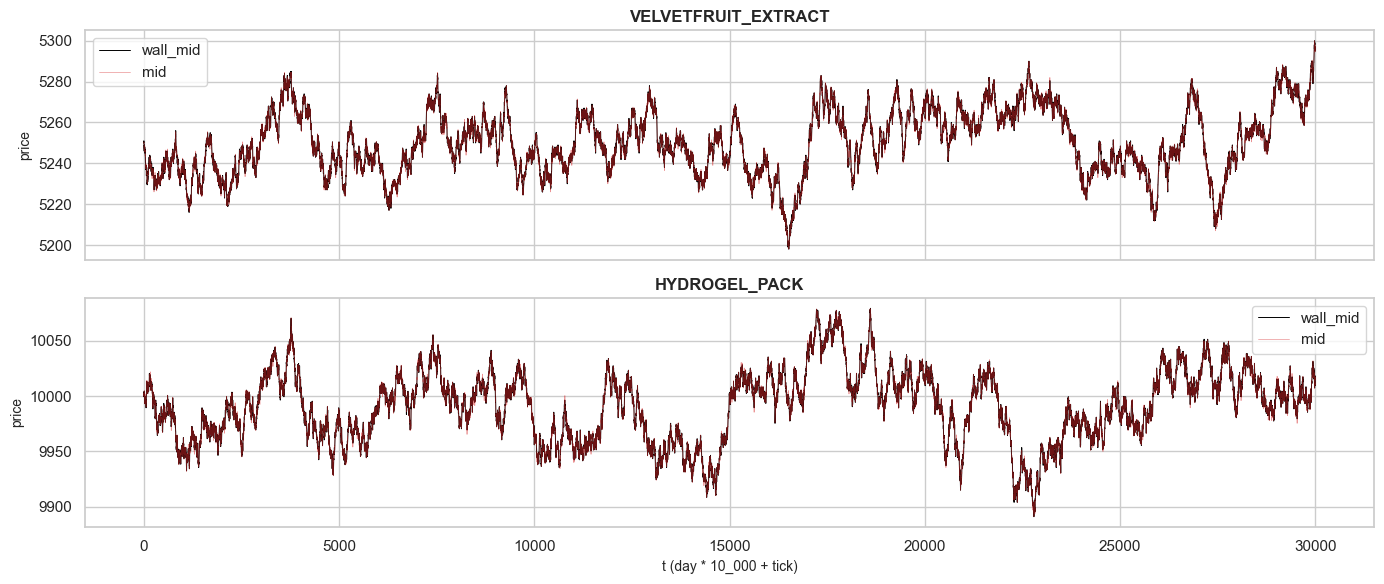

,mean,std,ret_std,lag1_mid,adf_p
symbol,,,,,
VELVETFRUIT_EXTRACT,5250.1174,15.6273,0.9816,0.9980,0.0
HYDROGEL_PACK,9990.8192,31.9336,1.9191,0.9982,0.0


In [71]:
try:
    from statsmodels.tsa.stattools import adfuller
    HAVE_ADF = True
except Exception:                         # statsmodels may be missing
    HAVE_ADF = False
    print("statsmodels not installed — skipping ADF tests.")


fig, axes = plt.subplots(len(SPOT_SYMBOLS), 1, figsize=(14, 6), sharex=True)
for ax, sym in zip(axes, SPOT_SYMBOLS):
    df = price_by_product[sym]
    sns.lineplot(data=df, x="t", y="wall_mid", ax=ax, color="black", lw=0.7, label="wall_mid")
    sns.lineplot(data=df, x="t", y="mid",      ax=ax, color="tab:red", lw=0.5, alpha=0.5, label="mid")
    ax.set_title(sym)
    ax.set_ylabel("price")
axes[-1].set_xlabel("t (day * 10_000 + tick)")
fig.tight_layout()
plt.show()


rows = []
for sym in SPOT_SYMBOLS:
    x = price_by_product[sym]["wall_mid"].dropna().to_numpy()
    lag1 = np.corrcoef(x[:-1], x[1:])[0, 1]
    ret  = np.diff(x)
    row = {"symbol": sym, "mean": x.mean(), "std": x.std(),
           "ret_std": ret.std(), "lag1_mid": lag1}
    if HAVE_ADF:
        adf_stat, adf_p, *_ = adfuller(x, maxlag=20)
        row["adf_p"] = adf_p
    rows.append(row)
display(pd.DataFrame(rows).set_index("symbol").round(4))


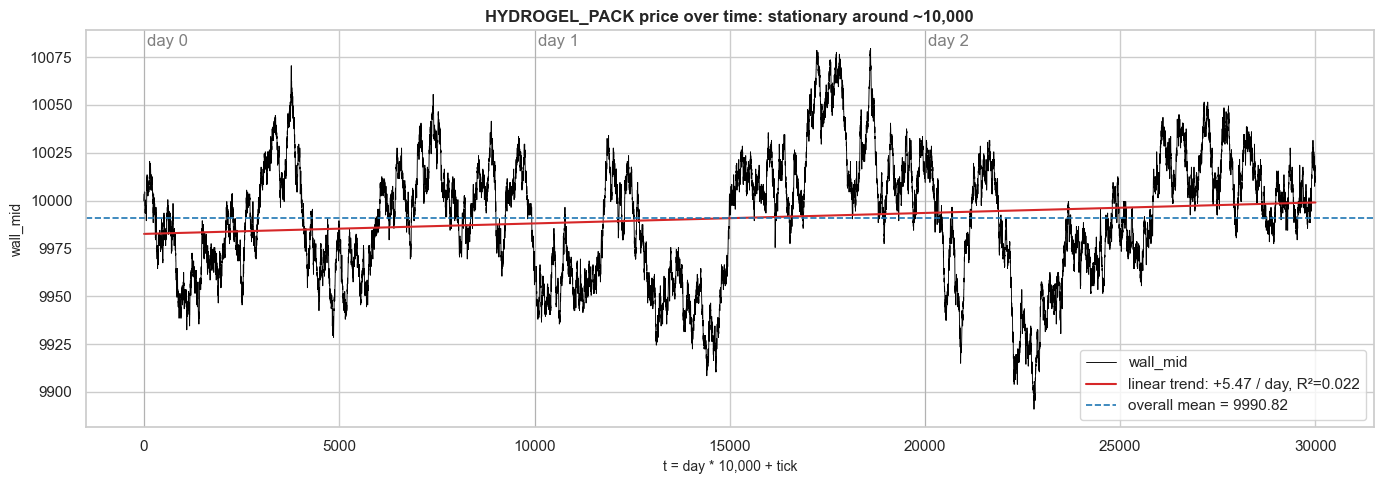

,start,end,mean,std,min,max,net
day,,,,,,,
0,10000.0,9957.5,9990.985,25.313,9928.5,10070.5,-42.5
1,9957.5,10014.5,9992.055,37.614,9908.5,10079.5,57.0
2,10011.5,10009.5,9989.418,31.630,9891.0,10051.5,-2.0


**HYDROGEL_PACK behavior:** stationary / mean-reverting around ~10,000, not a meaningful drift product. Net move over the sample is +9.5; linear trend is +5.47 per 10k-tick day with low R²=0.022; ADF p=1.38e-05.

In [72]:
# HYDROGEL_PACK: price-time view with drift check.
hydrogel = price_by_product[HYDROGEL].copy()
hydrogel = hydrogel.sort_values("t")

x_t = hydrogel["t"].to_numpy(dtype=float)
y_mid = hydrogel["wall_mid"].to_numpy(dtype=float)
slope, intercept = np.polyfit(x_t, y_mid, 1)
trend = slope * x_t + intercept
overall_mean = float(np.nanmean(y_mid))
net_move = float(y_mid[-1] - y_mid[0])
trend_per_day = float(slope * TICKS_PER_DAY)
trend_r2 = 1 - np.nansum((y_mid - trend) ** 2) / np.nansum((y_mid - overall_mean) ** 2)

adf_p = np.nan
if HAVE_ADF:
    adf_p = float(adfuller(pd.Series(y_mid).dropna(), autolag="AIC")[1])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hydrogel["t"], hydrogel["wall_mid"], color="black", lw=0.65, label="wall_mid")
ax.plot(hydrogel["t"], trend, color="tab:red", lw=1.5,
        label=f"linear trend: {trend_per_day:+.2f} / day, R²={trend_r2:.3f}")
ax.axhline(overall_mean, color="tab:blue", ls="--", lw=1.2,
           label=f"overall mean = {overall_mean:.2f}")

for day in sorted(hydrogel["day"].unique()):
    day_start = day * TICKS_PER_DAY
    ax.axvline(day_start, color="grey", lw=0.7, alpha=0.35)
    ax.text(day_start + 80, ax.get_ylim()[1] - 2, f"day {day}", color="grey", va="top")

ax.set_title(f"{HYDROGEL} price over time: stationary around ~10,000")
ax.set_xlabel("t = day * 10,000 + tick")
ax.set_ylabel("wall_mid")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

hydrogel_daily = (
    hydrogel.groupby("day")["wall_mid"]
    .agg(start="first", end="last", mean="mean", std="std", min="min", max="max")
)
hydrogel_daily["net"] = hydrogel_daily["end"] - hydrogel_daily["start"]
display(hydrogel_daily.round(3))

display(Markdown(
    f"**HYDROGEL_PACK behavior:** stationary / mean-reverting around ~10,000, "
    f"not a meaningful drift product. Net move over the sample is {net_move:+.1f}; "
    f"linear trend is {trend_per_day:+.2f} per 10k-tick day with low R²={trend_r2:.3f}; "
    f"ADF p={adf_p:.2e}."
))

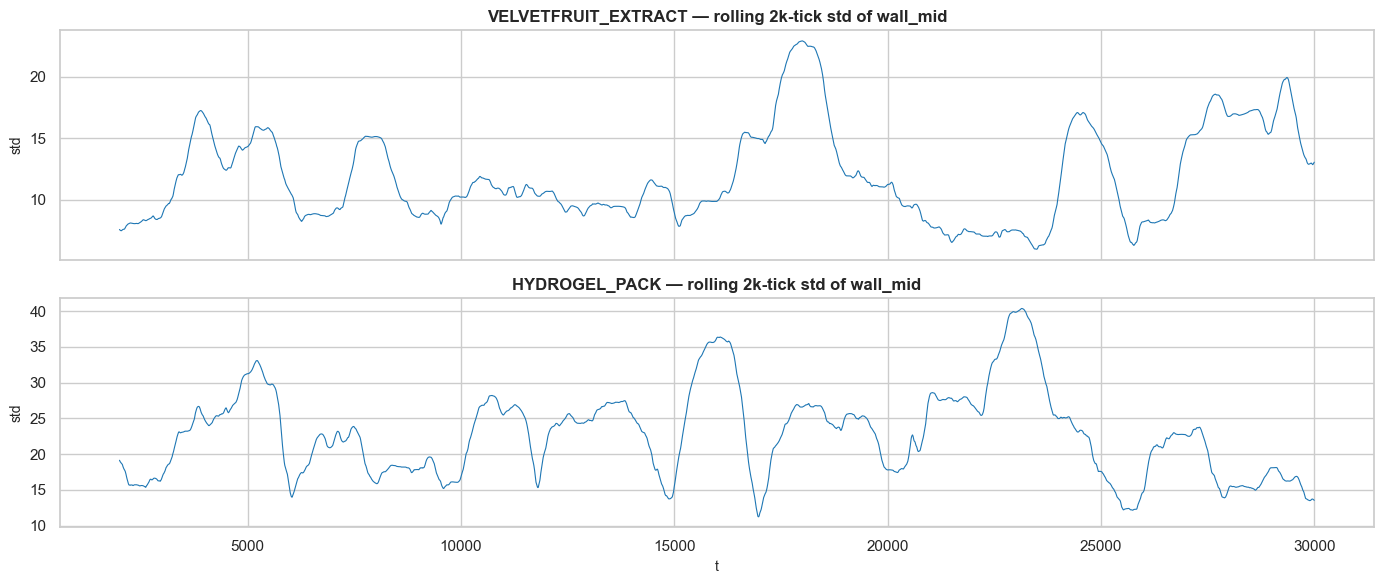

**Takeaway:** `HYDROGEL_PACK` sits tightly around ~10,000 (Osmium archetype). `VELVETFRUIT_EXTRACT` drifts in a narrow band around ~5,250 — small absolute vol but critical for the voucher pricing below.

In [73]:
# Rolling std per spot product — a quick visual check of vol stationarity.
fig, axes = plt.subplots(len(SPOT_SYMBOLS), 1, figsize=(14, 6), sharex=True)
for ax, sym in zip(axes, SPOT_SYMBOLS):
    df = price_by_product[sym]
    roll = df["wall_mid"].rolling(2000).std()
    sns.lineplot(x=df["t"], y=roll, ax=ax, color="tab:blue", lw=0.8)
    ax.set_title(f"{sym} — rolling 2k-tick std of wall_mid")
    ax.set_ylabel("std")
axes[-1].set_xlabel("t")
fig.tight_layout()
plt.show()

display(Markdown("**Takeaway:** `HYDROGEL_PACK` sits tightly around ~10,000 (Osmium archetype). "
                 "`VELVETFRUIT_EXTRACT` drifts in a narrow band around ~5,250 — small absolute vol but "
                 "critical for the voucher pricing below."))


## 3b. `VELVETFRUIT_EXTRACT` Stationarity and Linear Trend Check

### Purpose
- Test whether `VELVETFRUIT_EXTRACT` is stationary enough to trade as a tight spot market-making product.
- Fit a linear regression of `wall_mid ~ t` and check whether the trend is statistically significant.

### Expected Result
- ADF / KPSS-style stationarity diagnostics for the underlying.
- OLS slope, p-value, R², and per-day trend magnitude.
- A verdict: direct MM candidate vs hedge-only underlying.

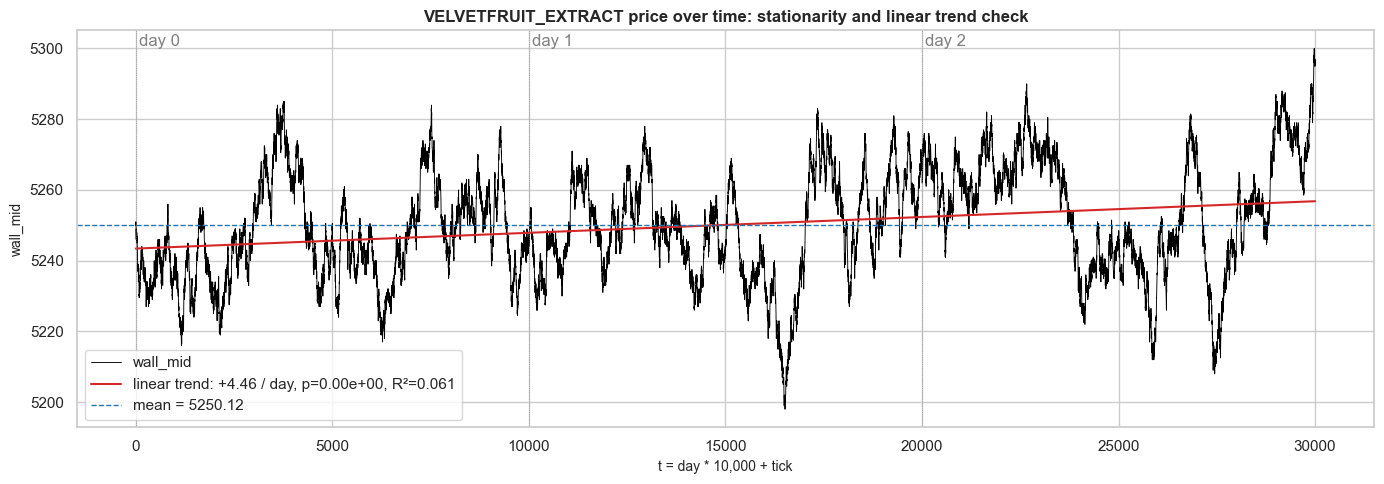

,value
metric,
mean,5250.117367
std,15.627323
net_move,45.000000
slope_per_tick,0.000446
trend_per_10k_tick_day,4.464364
linear_p_value,0.000000
linear_r2,0.061208
adf_stat,-4.825449
adf_p_value,0.000049


,start,end,mean,std,min,max,move
day,,,,,,,
0,5250.0,5244.0,5246.529,13.669,5216.0,5285.0,-6.0
1,5245.0,5265.5,5248.414,14.616,5198.0,5283.0,20.5
2,5267.0,5295.0,5255.409,16.985,5208.0,5300.0,28.0


**VELVETFRUIT_EXTRACT regime:** statistically significant but small linear drift versus intraday dispersion. Trend is +4.46 per 10k-tick day with R²=0.061; linear-regression p=0.00e+00. ADF rejects a unit root; KPSS rejects level-stationarity. Treat as hedge-first; only MM with conservative edges because the price path is very persistent.

In [74]:
from scipy import stats

velvet = price_by_product[VELVET].copy()
velvet_y = velvet["wall_mid"].astype(float).to_numpy()
velvet_t = velvet["t"].astype(float).to_numpy()
velvet_t0 = velvet_t - velvet_t[0]

lr = stats.linregress(velvet_t0, velvet_y)
trend = lr.intercept + lr.slope * velvet_t0
trend_per_day = lr.slope * TICKS_PER_DAY
trend_r2 = lr.rvalue ** 2
net_move = velvet_y[-1] - velvet_y[0]

adf_stat = np.nan
adf_p = np.nan
kpss_stat = np.nan
kpss_p = np.nan
if HAVE_ADF:
    from statsmodels.tsa.stattools import adfuller, kpss
    import warnings

    adf_stat, adf_p, *_ = adfuller(pd.Series(velvet_y).dropna(), autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(pd.Series(velvet_y).dropna(), regression="c", nlags="auto")

velvet_daily = (
    velvet.groupby("day")["wall_mid"]
    .agg(start="first", end="last", mean="mean", std="std", min="min", max="max")
)
velvet_daily["move"] = velvet_daily["end"] - velvet_daily["start"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(velvet["t"], velvet["wall_mid"], color="black", lw=0.65, label="wall_mid")
ax.plot(velvet["t"], trend, color="tab:red", lw=1.5,
        label=f"linear trend: {trend_per_day:+.2f} / day, p={lr.pvalue:.2e}, R²={trend_r2:.3f}")
ax.axhline(velvet_y.mean(), color="tab:blue", lw=1, ls="--", label=f"mean = {velvet_y.mean():.2f}")
for day in sorted(velvet["day"].dropna().unique()):
    day_start = day * TICKS_PER_DAY
    ax.axvline(day_start, color="grey", lw=0.5, ls=":")
    ax.text(day_start + 80, ax.get_ylim()[1] - 1, f"day {int(day)}", color="grey", va="top")
ax.set_title(f"{VELVET} price over time: stationarity and linear trend check")
ax.set_xlabel("t = day * 10,000 + tick")
ax.set_ylabel("wall_mid")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

summary = pd.DataFrame({
    "metric": [
        "mean",
        "std",
        "net_move",
        "slope_per_tick",
        "trend_per_10k_tick_day",
        "linear_p_value",
        "linear_r2",
        "adf_stat",
        "adf_p_value",
        "kpss_stat_level",
        "kpss_p_value_level",
    ],
    "value": [
        velvet_y.mean(),
        velvet_y.std(),
        net_move,
        lr.slope,
        trend_per_day,
        lr.pvalue,
        trend_r2,
        adf_stat,
        adf_p,
        kpss_stat,
        kpss_p,
    ],
}).set_index("metric")

display(summary.round(6))
display(velvet_daily.round(3))

trend_is_significant = lr.pvalue < 0.05
trend_is_economically_small = abs(trend_per_day) < velvet_y.std()
adf_rejects_unit_root = bool(np.isfinite(adf_p) and adf_p < 0.05)
kpss_rejects_level_stationary = bool(np.isfinite(kpss_p) and kpss_p < 0.05)

if trend_is_significant and not trend_is_economically_small:
    regime = "statistically significant and economically visible linear drift"
elif trend_is_significant:
    regime = "statistically significant but small linear drift versus intraday dispersion"
else:
    regime = "no statistically significant linear trend"

stationary_note = (
    "ADF rejects a unit root" if adf_rejects_unit_root else "ADF does not reject a unit root"
)
if np.isfinite(kpss_p):
    stationary_note += "; KPSS rejects level-stationarity" if kpss_rejects_level_stationary else "; KPSS does not reject level-stationarity"

mm_note = (
    "Treat as hedge-first; only MM with conservative edges because the price path is very persistent."
    if trend_is_significant or kpss_rejects_level_stationary
    else "Stationarity diagnostics are benign enough for a small-edge MM trial."
)

display(Markdown(
    f"**VELVETFRUIT_EXTRACT regime:** {regime}. "
    f"Trend is {trend_per_day:+.2f} per 10k-tick day with R²={trend_r2:.3f}; "
    f"linear-regression p={lr.pvalue:.2e}. {stationary_note}. {mm_note}"
))

## 4. Underlying Volatility for Option Pricing

### Purpose
- Estimate realised volatility of `VELVETFRUIT_EXTRACT` at the tick level and annualise it.
- Check whether σ is stable enough to use a single constant in a BSM baseline.

### Expected Result
- `sigma_hat` — a scalar annualised vol that feeds section 5b.
- A rolling sigma plot that shows how much the constant-vol assumption misses.

### Intuition
- If sigma is nearly flat over the 3 days, a constant-vol BSM baseline is defensible.
- Any drift in sigma motivates the per-timestamp smile fit in section 5c/5d.


Tick-level log-return std:  0.000187
Annualised sigma_hat:       0.3572


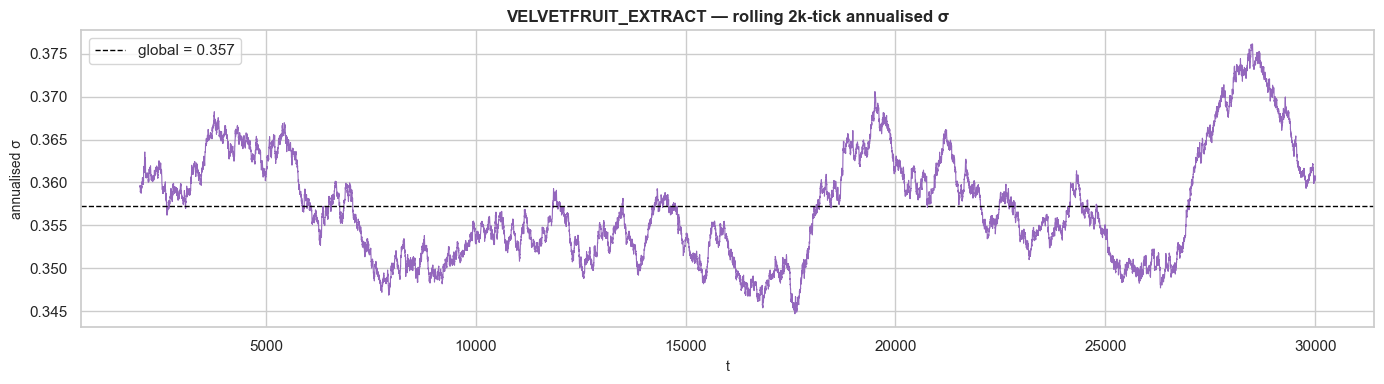

In [75]:
velvet = price_by_product[VELVET].copy()
velvet["log_ret"] = np.log(velvet["wall_mid"]).diff()

tick_vol     = velvet["log_ret"].std(skipna=True)
sigma_hat    = tick_vol * np.sqrt(YEAR_TICKS)           # annualised
print(f"Tick-level log-return std:  {tick_vol:.6f}")
print(f"Annualised sigma_hat:       {sigma_hat:.4f}")

rolling = velvet["log_ret"].rolling(2000).std() * np.sqrt(YEAR_TICKS)
plt.figure(figsize=(14, 4))
sns.lineplot(x=velvet["t"], y=rolling, color="tab:purple", lw=0.8)
plt.axhline(sigma_hat, color="black", ls="--", lw=1, label=f"global = {sigma_hat:.3f}")
plt.legend()
plt.title(f"{VELVET} — rolling 2k-tick annualised σ")
plt.xlabel("t"); plt.ylabel("annualised σ")
plt.tight_layout(); plt.show()


## 5. Voucher Pricing — Fair-Value Candidates

We try three fair-value models for the 10 `VEV_<K>` calls and compare them. First, a bit of setup: build a wide matrix of voucher wall-mids aligned against the underlying wall-mid, then compute TTE per tick.


In [76]:
# Wide matrix: index = (day, timestamp), columns = strikes → wall_mid.
wide_mid = (
    pd.concat(
        [price_by_product[f"VEV_{k}"].assign(strike=k)[["day", "timestamp", "wall_mid", "strike"]]
         for k in VEV_STRIKES],
        ignore_index=True,
    )
    .pivot_table(index=["day", "timestamp"], columns="strike", values="wall_mid")
    .sort_index()
)

# Align underlying S on the same (day, timestamp) grid.
S_series = (
    price_by_product[VELVET]
        .set_index(["day", "timestamp"])["wall_mid"]
        .reindex(wide_mid.index)
        .ffill()
)

# TTE in years, one value per row.
days_arr  = wide_mid.index.get_level_values("day").to_numpy()
ticks_arr = wide_mid.index.get_level_values("timestamp").to_numpy() // 100
tte_days  = np.vectorize(lambda d: DAY_TO_TTE_DAYS[d])(days_arr) - ticks_arr / TICKS_PER_DAY
tte_years = tte_days / 365.0

print(f"wide_mid shape: {wide_mid.shape}")
print(f"TTE (years) range: [{tte_years.min():.4f}, {tte_years.max():.4f}]")
wide_mid.head()


wide_mid shape: (30000, 10)
TTE (years) range: [0.0110, 0.0192]


strike           4000   4500   5000   5100   5200  5300  5400  5500  6000  \
day timestamp                                                               
0   0          1250.0  750.0  257.5  171.5  102.0  52.5  23.0   8.5   0.5   
    100        1251.0  751.0  258.0  172.5  102.5  53.0  23.5   8.5   0.5   
    200        1250.0  750.0  257.5  171.5  102.0  52.5  23.0   8.5   0.5   
    300        1250.0  750.0  257.5  172.0  102.0  52.5  23.0   8.5   0.5   
    400        1250.0  750.0  257.5  172.0  102.0  52.5  23.0   8.5   0.5   

strike         6500  
day timestamp        
0   0           0.5  
    100         0.5  
    200         0.5  
    300         0.5  
    400         0.5

### 5a. No-arbitrage Lower Bound

`C(K) >= max(S - K, 0)`. Any violation is a pure arb.  We compute the extrinsic
value `voucher_mid - max(S - K, 0)` per strike and report its min / fraction
negative.  Persistent negatives would be a red flag (and a trade).


,min_extrinsic,frac_negative,mean_extrinsic
strike,,,
4000,-0.5,0.0731,-0.0009
4500,-0.5,0.1096,-0.0000
5000,1.0,0.0000,4.9058
5100,5.0,0.0000,16.6898
5200,22.0,0.0000,45.4368
5300,27.0,0.0000,46.7620
5400,6.5,0.0000,15.9532
5500,2.5,0.0000,6.6416
6000,0.5,0.0000,0.5000


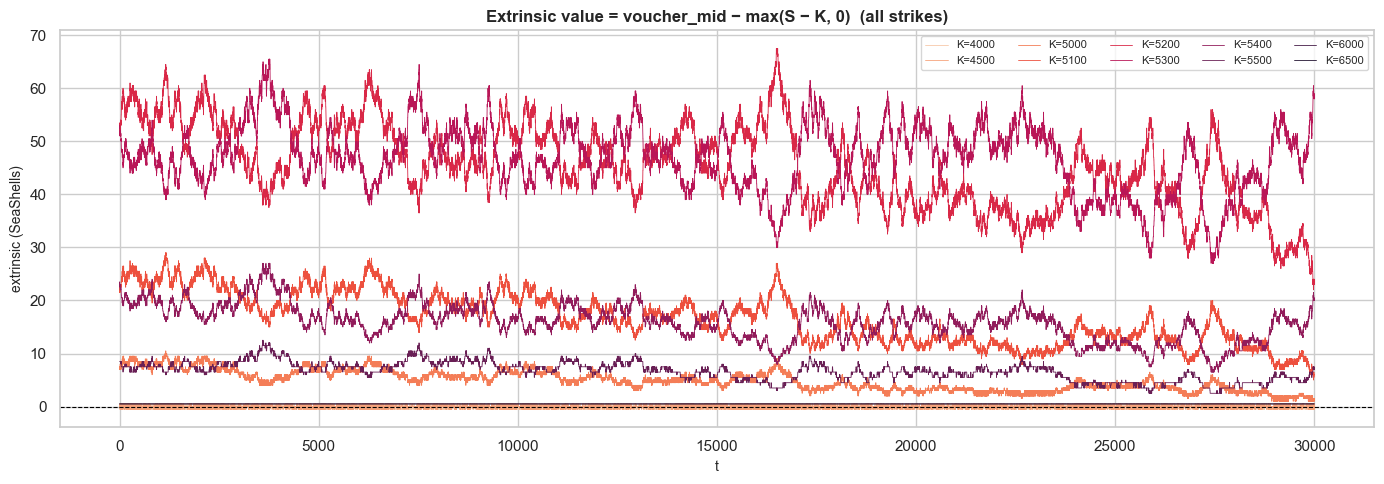

In [77]:
S_arr   = S_series.to_numpy()[:, None]            # (T, 1)
K_arr   = np.array(VEV_STRIKES, dtype=float)[None, :]   # (1, K)
C_mkt   = wide_mid.to_numpy()                     # (T, K)

intrinsic = np.maximum(S_arr - K_arr, 0.0)
extrinsic = C_mkt - intrinsic

summary_arb = pd.DataFrame({
    "strike":           VEV_STRIKES,
    "min_extrinsic":    np.nanmin(extrinsic, axis=0),
    "frac_negative":    np.nanmean(extrinsic < 0, axis=0),
    "mean_extrinsic":   np.nanmean(extrinsic, axis=0),
}).set_index("strike")
display(summary_arb.round(4))

plt.figure(figsize=(14, 5))
for k in VEV_STRIKES:
    plt.plot(wide_mid.index.get_level_values("day") * TICKS_PER_DAY +
             wide_mid.index.get_level_values("timestamp") // 100,
             extrinsic[:, VEV_STRIKES.index(k)],
             color=STRIKE_COLORS[k], lw=0.6, label=f"K={k}")
plt.axhline(0, color="black", ls="--", lw=0.8)
plt.title("Extrinsic value = voucher_mid − max(S − K, 0)  (all strikes)")
plt.xlabel("t"); plt.ylabel("extrinsic (SeaShells)")
plt.legend(ncol=5, fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()


### 5b. BSM with Constant σ

Price every voucher using `sigma_hat` from section 4 and look at the per-strike
pricing error `voucher_mid − bsm`.  If this error is small and unbiased, a
constant-σ BSM would be a viable FV baseline.


,rmse_flat,bias_flat,n
strike,,,
4000,0.190,-0.001,30000
4500,0.236,-0.019,30000
5000,10.717,-10.326,30000
5100,18.221,-17.989,30000
5200,23.282,-23.043,30000
5300,22.908,-22.616,30000
5400,21.016,-20.775,30000
5500,11.209,-10.898,30000
6000,0.405,0.398,30000


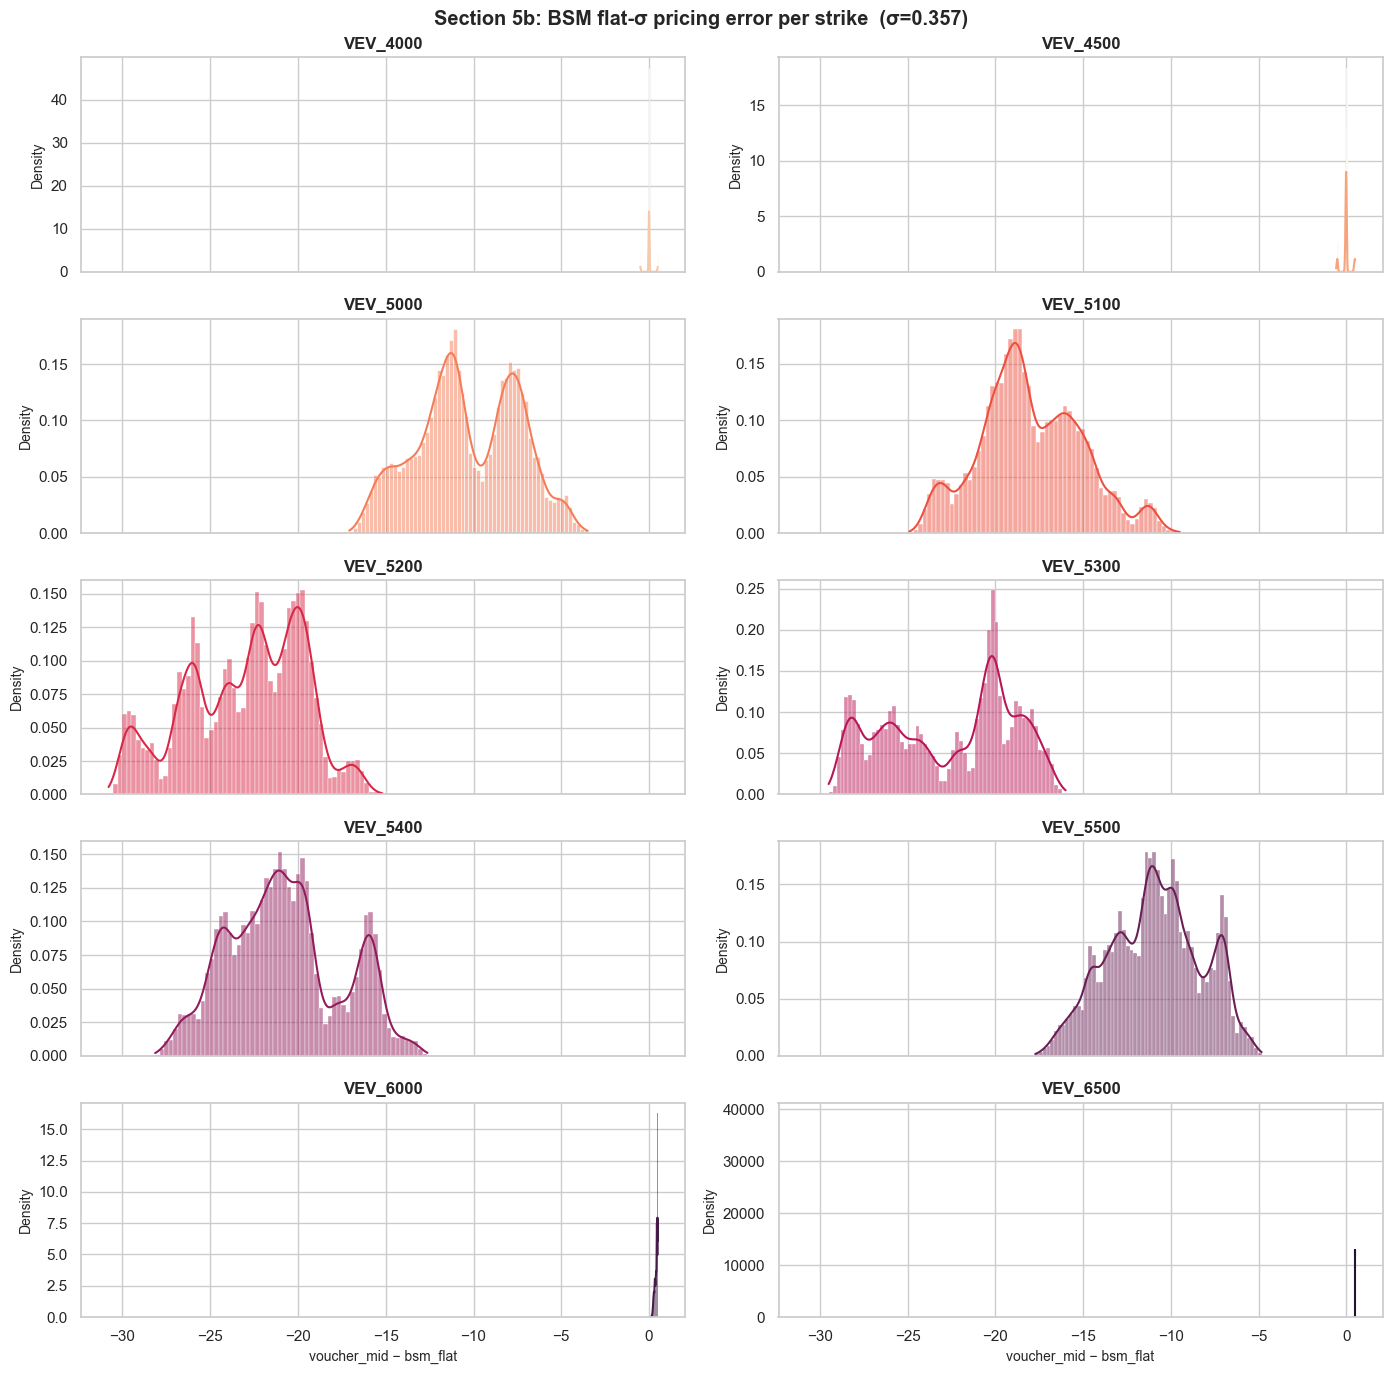

In [78]:
T_arr   = tte_years[:, None]                       # (T, 1)
K_arr2  = np.broadcast_to(K_arr,  C_mkt.shape)
S_arr2  = np.broadcast_to(S_arr,  C_mkt.shape)
T_arr2  = np.broadcast_to(T_arr,  C_mkt.shape)

bsm_flat = bs_call(S_arr2, K_arr2, T_arr2, sigma_hat)
err_flat = C_mkt - bsm_flat

rows = []
for i, k in enumerate(VEV_STRIKES):
    e = err_flat[:, i]
    e = e[np.isfinite(e)]
    rows.append({"strike": k,
                 "rmse_flat": np.sqrt(np.mean(e ** 2)),
                 "bias_flat": e.mean(),
                 "n": e.size})
display(pd.DataFrame(rows).set_index("strike").round(3))

# Histogram per strike of the pricing error
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
for ax, k in zip(axes.flat, VEV_STRIKES):
    e = err_flat[:, VEV_STRIKES.index(k)]
    sns.histplot(e[np.isfinite(e)], bins=60, ax=ax,
                 color=STRIKE_COLORS[k], stat="density", kde=True)
    ax.set_title(f"VEV_{k}")
    ax.set_xlabel("voucher_mid − bsm_flat")
fig.suptitle(f"Section 5b: BSM flat-σ pricing error per strike  (σ={sigma_hat:.3f})",
             fontweight="bold")
fig.tight_layout()
plt.show()


### 5c. Implied-Vol Smile & Per-Timestamp Parabola Fit

Solve IV per (tick, strike) via vectorised bisection, compute moneyness
`m = log(K / S) / sqrt(T)`, then fit `IV(m) = a·m² + b·m + c` **per timestamp**
across the (up to) 10 strikes available. The `(a_t, b_t, c_t)` trajectory is
the raw material for the scalping signal in 5d.


IV valid fraction: 1.000


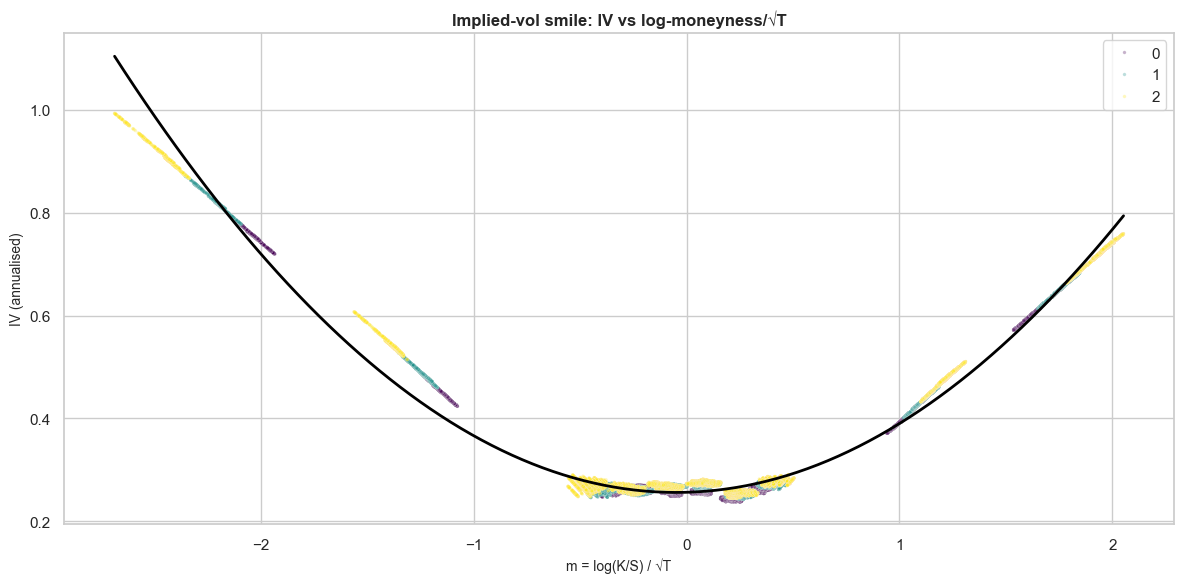

In [79]:
iv_obs = implied_vol(C_mkt, S_arr2, K_arr2, T_arr2)   # (T, K)
# Moneyness m = log(K/S)/sqrt(T)
with np.errstate(divide="ignore", invalid="ignore"):
    moneyness = np.log(K_arr2 / S_arr2) / np.sqrt(T_arr2)

# Aggregate smile: average IV per strike per day
iv_df = (
    pd.DataFrame(iv_obs, columns=VEV_STRIKES, index=wide_mid.index)
      .stack()
      .rename("iv")
      .reset_index()
      .rename(columns={"level_2": "strike"})
)
m_df = (
    pd.DataFrame(moneyness, columns=VEV_STRIKES, index=wide_mid.index)
      .stack()
      .rename("m")
      .reset_index()
      .rename(columns={"level_2": "strike"})
)
smile_df = iv_df.merge(m_df, on=["day", "timestamp", "strike"])
print(f"IV valid fraction: {smile_df['iv'].notna().mean():.3f}")

# Plot mean IV vs moneyness per day with a 2nd-order regression overlay.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=smile_df.dropna(), x="m", y="iv",
                hue="day", palette="viridis", s=6, alpha=0.3)
sns.regplot(data=smile_df.dropna(), x="m", y="iv",
            order=2, scatter=False, color="black",
            line_kws={"lw": 2, "label": "pooled parabola"})
plt.title("Implied-vol smile: IV vs log-moneyness/√T")
plt.xlabel("m = log(K/S) / √T"); plt.ylabel("IV (annualised)")
plt.legend()
plt.tight_layout(); plt.show()


Smile parameter summary:


,a,b,c
count,30000.0000,30000.0000,30000.0000
mean,0.1211,0.0152,0.2559
std,0.0100,0.0125,0.0047
min,0.0972,-0.0157,0.2465
25%,0.1126,0.0057,0.2525
50%,0.1197,0.0165,0.2557
75%,0.1305,0.0252,0.2590
max,0.1427,0.0496,0.2776


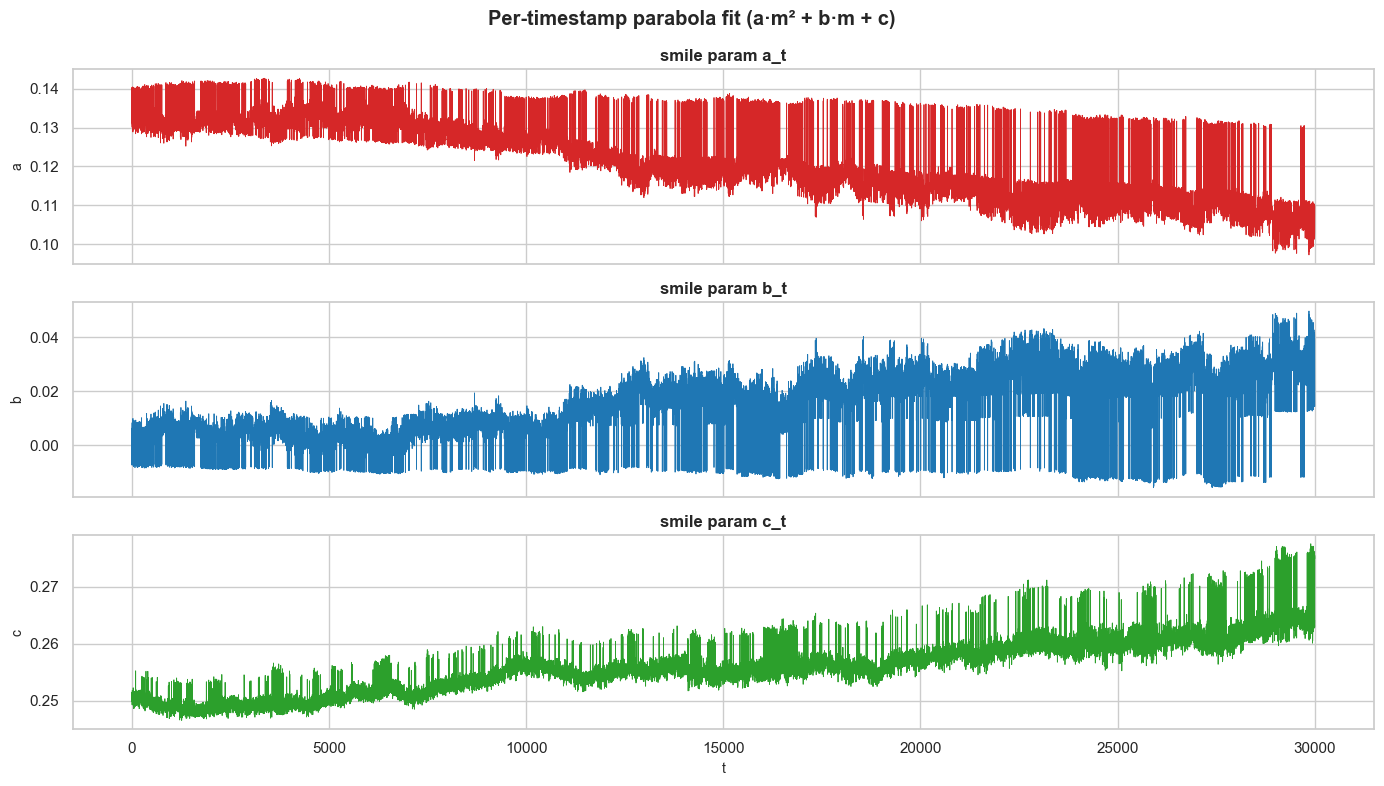

In [80]:
a_t, b_t, c_t = fit_smile_parabola(moneyness, iv_obs)

fit_frame = pd.DataFrame({"a": a_t, "b": b_t, "c": c_t}, index=wide_mid.index)
print("Smile parameter summary:")
display(fit_frame.describe().round(4))

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
t_axis = wide_mid.index.get_level_values("day") * TICKS_PER_DAY + wide_mid.index.get_level_values("timestamp") // 100
for ax, col, c in zip(axes, ["a", "b", "c"], ["tab:red", "tab:blue", "tab:green"]):
    sns.lineplot(x=t_axis, y=fit_frame[col].to_numpy(), ax=ax, color=c, lw=0.6)
    ax.set_title(f"smile param {col}_t"); ax.set_ylabel(col)
axes[-1].set_xlabel("t")
fig.suptitle("Per-timestamp parabola fit (a·m² + b·m + c)", fontweight="bold")
fig.tight_layout()
plt.show()


### 5d. Smile-Detrended Scalping Signal

Pipeline (exactly the one we want to test):

1. **Detrend IV**: `iv_resid = iv_obs − IV_fit(m)`.  By construction, this
   residual is orthogonal to moneyness at every tick — it isolates
   strike-specific richness / cheapness.
2. **Theoretical fair price**: plug `IV_fit_t(m)` back into BSM to get
   `C_fit = bs_call(S, K, T, IV_fit(m))`.
3. **Price deviation**: `dev = voucher_mid − C_fit`.  A mean-reverting `dev`
   series is the scalping signal.
4. **Stats per strike**: AR(1) φ, half-life, ±σ bands, tail fractions.
5. **Emphasis on the ATM-equivalent strike** (the one closest to the daily
   mean of `VELVETFRUIT_EXTRACT` ≈ 5,250, i.e. `VEV_5200` or `VEV_5300`) —
   same role as the "10000-strike call" in the prior round.

Output: a summary table that ranks strikes by half-life and `|dev|` so the
trader can prioritise the most scalpable strikes.


In [81]:
# 1) Evaluate the fitted parabola on each (tick, strike) — same shape as iv_obs
iv_fit = a_t[:, None] * moneyness ** 2 + b_t[:, None] * moneyness + c_t[:, None]
iv_resid = iv_obs - iv_fit                             # 去趋势后的 IV 残差

# 2) Theoretical BSM price using the smile-implied IV
C_fit = bs_call(S_arr2, K_arr2, T_arr2, iv_fit)

# 3) Price-space deviation
dev = C_mkt - C_fit

# Wrap into tidy DataFrames, aligned to wide_mid's (day, timestamp) index.
iv_resid_df = pd.DataFrame(iv_resid, columns=VEV_STRIKES, index=wide_mid.index)
dev_df      = pd.DataFrame(dev,      columns=VEV_STRIKES, index=wide_mid.index)

print("IV residual summary:")
display(iv_resid_df.describe().round(4))
print("\nPrice deviation summary (SeaShells):")
display(dev_df.describe().round(3))


IV residual summary:


,4000,4500,5000,5100,5200,5300,5400,5500,6000,6500
count,2141.0000,3288.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000
mean,-0.0106,0.0212,-0.0054,0.0020,0.0086,0.0091,-0.0158,-0.0081,0.0116,-0.0037
std,0.0114,0.0235,0.0049,0.0048,0.0035,0.0039,0.0054,0.0052,0.0075,0.0035
min,-0.0349,0.0008,-0.0320,-0.0193,-0.0080,-0.0047,-0.0336,-0.0288,-0.0031,-0.0211
25%,-0.0186,0.0036,-0.0076,-0.0004,0.0065,0.0060,-0.0193,-0.0116,0.0063,-0.0051
50%,-0.0112,0.0094,-0.0054,0.0023,0.0089,0.0086,-0.0169,-0.0078,0.0098,-0.0030
75%,0.0003,0.0371,-0.0030,0.0054,0.0111,0.0122,-0.0138,-0.0043,0.0159,-0.0016
max,0.0020,0.0894,0.0097,0.0134,0.0183,0.0205,0.0031,0.0100,0.0434,0.0091



Price deviation summary (SeaShells):


,4000,4500,5000,5100,5200,5300,5400,5500,6000,6500
count,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000
mean,-0.554,-0.156,-0.472,0.395,2.072,2.200,-2.682,-0.757,0.105,-0.027
std,0.439,0.210,0.425,0.835,0.823,0.897,0.840,0.411,0.055,0.025
min,-2.798,-0.865,-2.345,-2.859,-1.815,-1.040,-5.139,-2.287,-0.038,-0.152
25%,-0.733,-0.240,-0.730,-0.062,1.563,1.541,-3.227,-1.059,0.066,-0.038
50%,-0.413,-0.092,-0.429,0.354,2.151,2.045,-2.854,-0.790,0.097,-0.023
75%,-0.263,-0.044,-0.210,0.996,2.606,2.847,-2.412,-0.477,0.141,-0.013
max,0.011,0.404,0.766,2.451,4.616,4.957,0.639,0.974,0.292,0.073


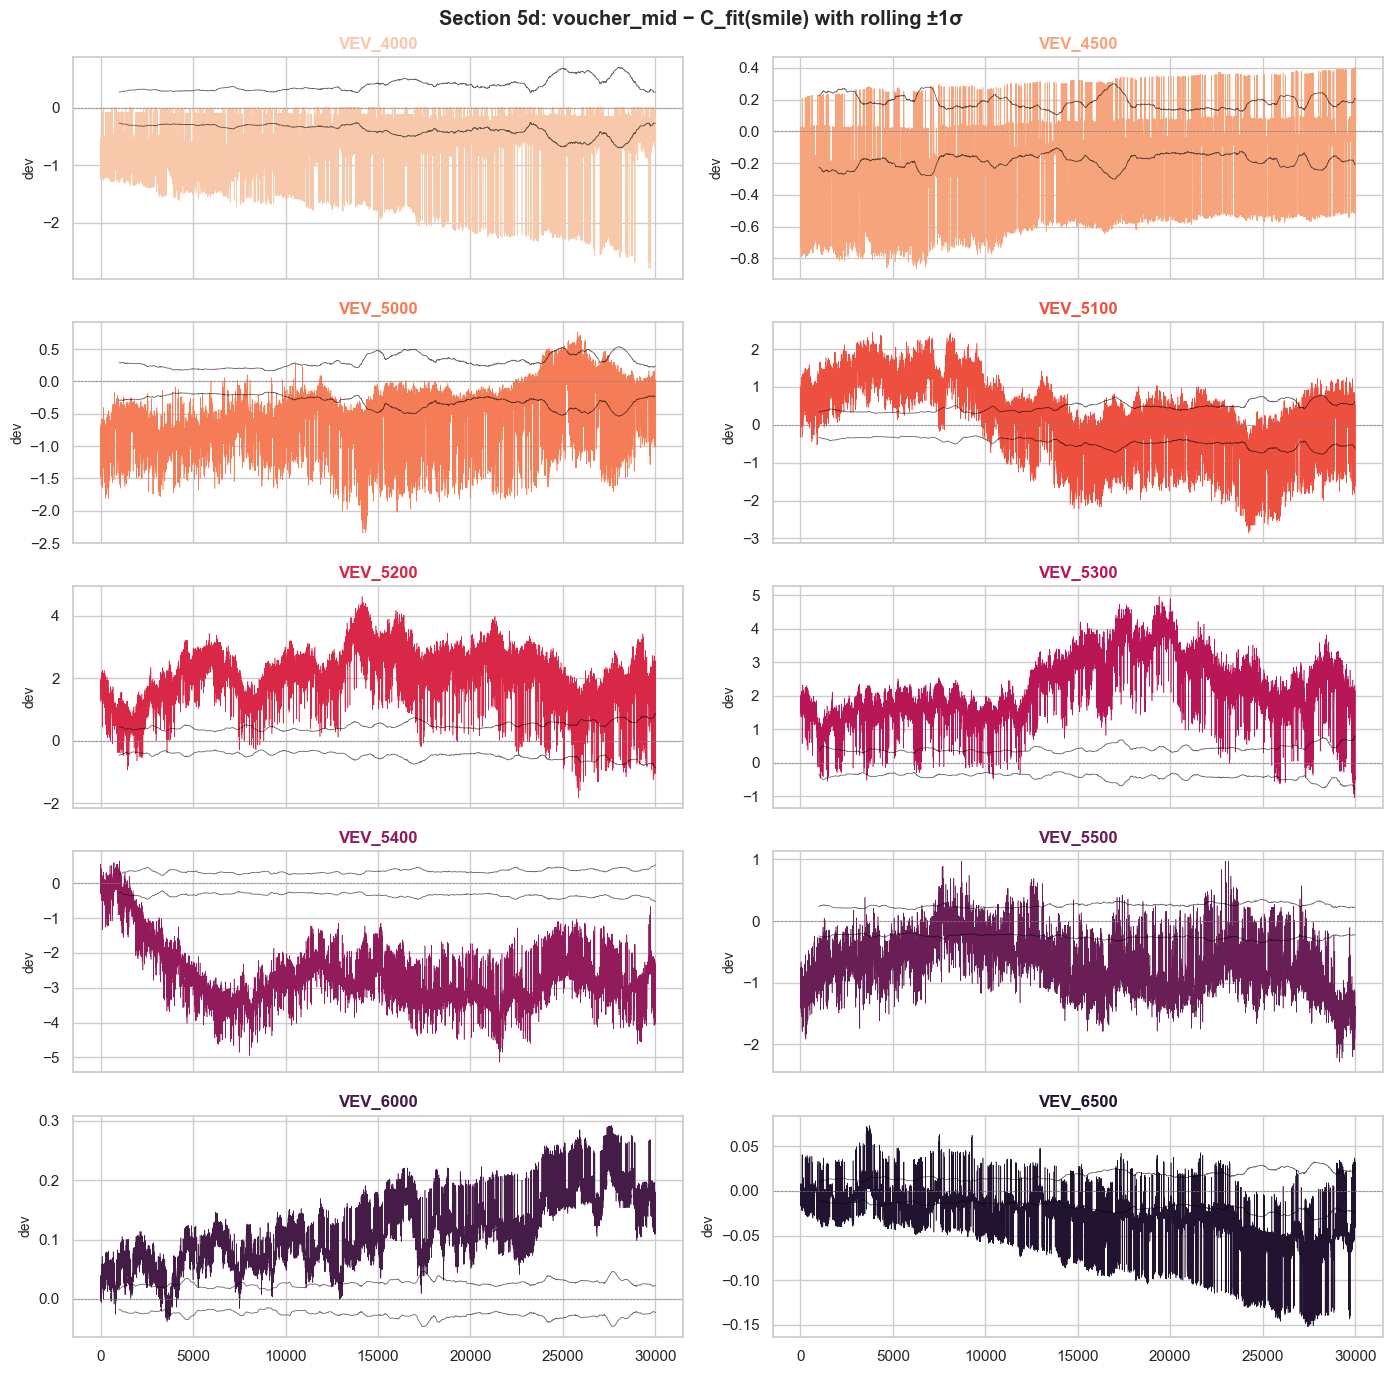

In [82]:
# Per-strike deviation time series with rolling ±1σ bands.
def _plot_dev(ax, k):
    s = dev_df[k]
    r_std = s.rolling(1000).std()
    ax.plot(t_axis, s.to_numpy(),                       lw=0.4, color=STRIKE_COLORS[k])
    ax.plot(t_axis, (+r_std).to_numpy(),                lw=0.6, color="black", alpha=0.6)
    ax.plot(t_axis, (-r_std).to_numpy(),                lw=0.6, color="black", alpha=0.6)
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_ylabel("dev")

panel_plot_by_strike(_plot_dev,
                     title="Section 5d: voucher_mid − C_fit(smile) with rolling ±1σ")


Daily mean S = 5250.12  →  ATM-equivalent strike = VEV_5300


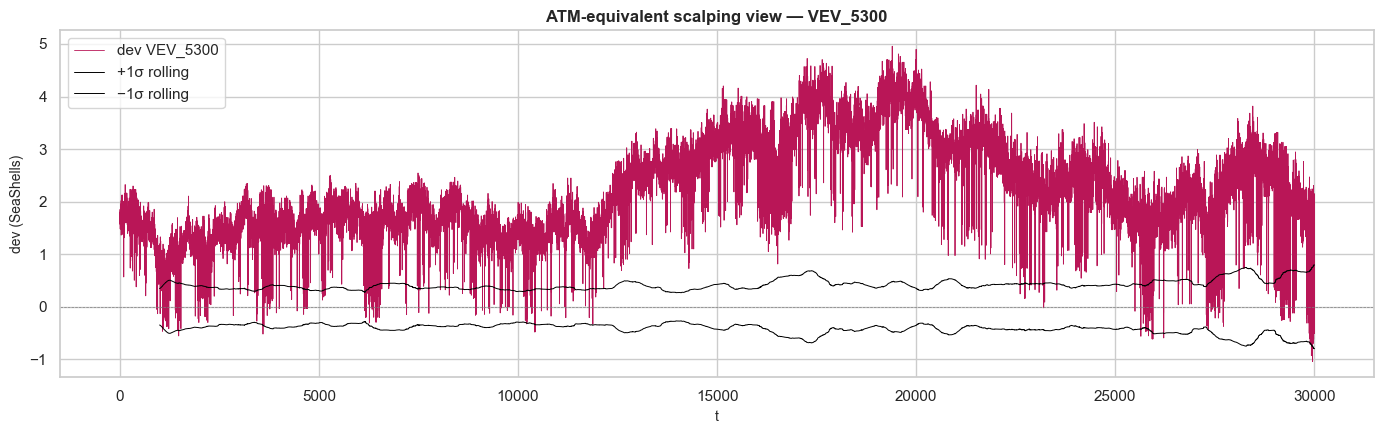

In [83]:
# Highlight the ATM-equivalent strike (closest to daily mean of VELVET)
s_mean = price_by_product[VELVET]["wall_mid"].mean()
atm_k  = min(VEV_STRIKES, key=lambda k: abs(k - s_mean))
print(f"Daily mean S = {s_mean:.2f}  →  ATM-equivalent strike = VEV_{atm_k}")

fig, ax = plt.subplots(figsize=(14, 4.5))
s   = dev_df[atm_k]
sd  = s.rolling(1000).std()
ax.plot(t_axis, s.to_numpy(),          color=STRIKE_COLORS[atm_k], lw=0.6,
        label=f"dev VEV_{atm_k}")
ax.plot(t_axis, (+sd).to_numpy(),      color="black", lw=0.7, label="+1σ rolling")
ax.plot(t_axis, (-sd).to_numpy(),      color="black", lw=0.7, label="−1σ rolling")
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_title(f"ATM-equivalent scalping view — VEV_{atm_k}")
ax.set_xlabel("t"); ax.set_ylabel("dev (SeaShells)")
ax.legend(); fig.tight_layout(); plt.show()


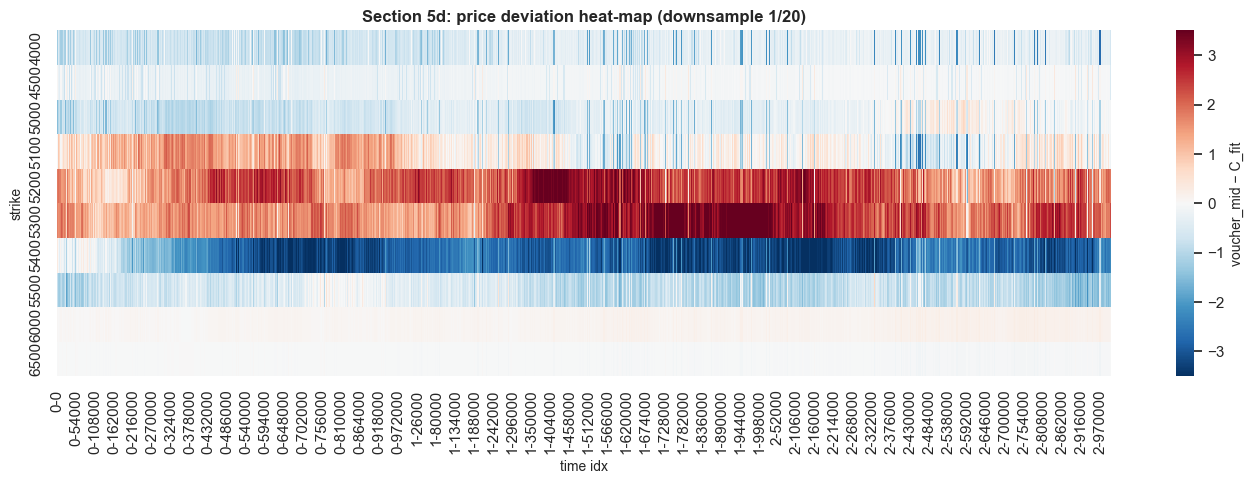

In [84]:
# Heatmap: strike × time of price deviation (downsampled so it fits on screen).
DOWN = max(1, len(dev_df) // 1500)
heat = dev_df.iloc[::DOWN].T                        # rows = strikes, cols = time
plt.figure(figsize=(14, 5))
vmax = np.nanpercentile(np.abs(heat.values), 98)
sns.heatmap(heat, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
            cbar_kws={"label": "voucher_mid − C_fit"})
plt.title(f"Section 5d: price deviation heat-map (downsample 1/{DOWN})")
plt.ylabel("strike"); plt.xlabel("time idx")
plt.tight_layout(); plt.show()


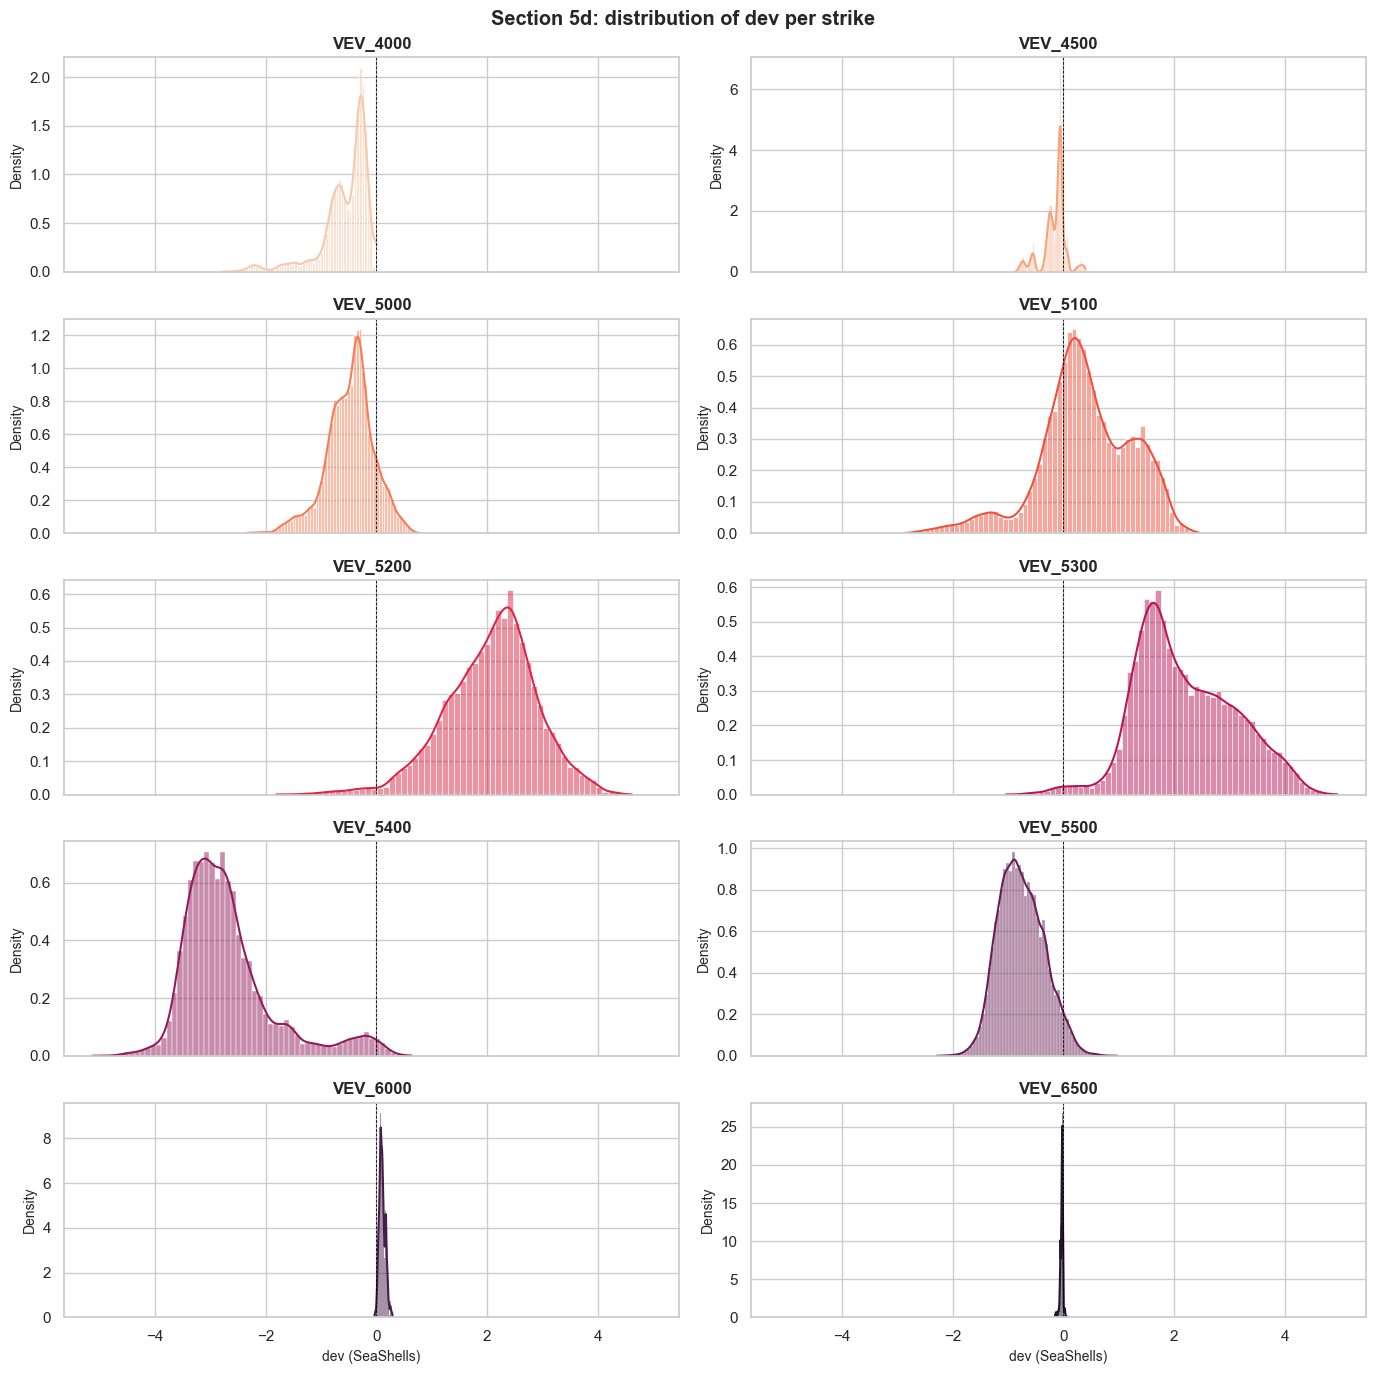

In [85]:
# Distribution of deviations per strike
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
for ax, k in zip(axes.flat, VEV_STRIKES):
    s = dev_df[k].dropna().to_numpy()
    sns.histplot(s, bins=60, ax=ax, color=STRIKE_COLORS[k],
                 stat="density", kde=True)
    ax.axvline(0, color="black", ls="--", lw=0.6)
    ax.set_title(f"VEV_{k}")
    ax.set_xlabel("dev (SeaShells)")
fig.suptitle("Section 5d: distribution of dev per strike", fontweight="bold")
fig.tight_layout()
plt.show()


In [86]:
# Scalping-readiness summary per strike
rows = []
for k in VEV_STRIKES:
    s = dev_df[k]
    phi, hl = ar1_halflife(s.to_numpy())
    spread = price_by_product[f"VEV_{k}"]["spread"].mean()
    sd     = s.std()
    rows.append({
        "strike":        k,
        "dev_std":       sd,
        "dev_iqr":       s.quantile(0.75) - s.quantile(0.25),
        "tail_gt_2σ":    (np.abs(s) > 2 * sd).mean(),
        "ar1_phi":       phi,
        "halflife_tk":   hl,
        "mean_spread":   spread,
        "edge_ratio":    sd / max(spread, 1e-6),       # >0.5 = worth trading
    })
scalp_df = pd.DataFrame(rows).set_index("strike")
display(scalp_df.round(4))

display(Markdown(
    "**Signal rule (candidate, not yet executed):** when `dev_t,K > +k·σ_roll`, sell "
    "the voucher and delta-hedge by buying `VELVETFRUIT_EXTRACT` using `bs_delta(S, K, T, IV_fit)`. "
    "When `dev_t,K < −k·σ_roll`, mirror (buy voucher, sell underlying). Exit on revert to 0 or "
    "after ~halflife_tk ticks.  Prioritise strikes with high `edge_ratio` AND short `halflife_tk`."
))


,dev_std,dev_iqr,tail_gt_2σ,ar1_phi,halflife_tk,mean_spread,edge_ratio
strike,,,,,,,
4000,0.4387,0.4707,0.1435,0.1902,0.4176,20.8135,0.0211
4500,0.2105,0.1958,0.1096,0.1851,0.4109,15.8527,0.0133
5000,0.4252,0.5202,0.1623,0.4798,0.9438,6.0433,0.0704
5100,0.8350,1.0576,0.0784,0.7105,2.0282,4.2958,0.1944
5200,0.8228,1.0429,0.7211,0.7222,2.1300,2.8881,0.2849
5300,0.8974,1.3064,0.6071,0.8497,4.2570,2.1068,0.4260
5400,0.8400,0.8154,0.8892,0.8818,5.5121,1.3814,0.6080
5500,0.4108,0.5815,0.4683,0.7514,2.4247,1.1498,0.3573
6000,0.0550,0.0747,0.3984,0.8905,5.9772,1.0000,0.0550


**Signal rule (candidate, not yet executed):** when `dev_t,K > +k·σ_roll`, sell the voucher and delta-hedge by buying `VELVETFRUIT_EXTRACT` using `bs_delta(S, K, T, IV_fit)`. When `dev_t,K < −k·σ_roll`, mirror (buy voucher, sell underlying). Exit on revert to 0 or after ~halflife_tk ticks.  Prioritise strikes with high `edge_ratio` AND short `halflife_tk`.

## 6. Flow & Trader-Pattern Analysis

### Purpose
- Inspect `trades` for named traders (Olivia-style signals).
- Measure trade volume per product, and whether underlying trades lead voucher moves.

### Expected Result
- Confirmation that `buyer`, `seller` fields are empty → no directed signal.
- A lagged-correlation table of underlying return vs voucher return.


In [87]:
print("Trade snapshot:")
display(trades.head())

has_names_buyer  = trades["buyer"].notna().mean()  if "buyer"  in trades else 0.0
has_names_seller = trades["seller"].notna().mean() if "seller" in trades else 0.0
print(f"\nNon-null buyer fraction:  {has_names_buyer:.3f}")
print(f"Non-null seller fraction: {has_names_seller:.3f}")

vol = (trades.assign(abs_q=trades["quantity"].abs())
             .groupby(["day", "symbol"])["abs_q"].sum()
             .unstack(fill_value=0))
display(vol)


Trade snapshot:


,timestamp,buyer,seller,symbol,currency,price,quantity,day,t
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0,25
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0,29
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0,29
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,0,29
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3,0,29



Non-null buyer fraction:  0.000
Non-null seller fraction: 0.000


symbol,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
day,,,,,,,,,,,,
0,1349,2689,351,0,0,0,15,128,218,281,320,320
1,1485,2685,333,1,1,1,22,130,286,321,345,345
2,1244,2895,256,0,0,0,26,162,283,335,337,337


In [88]:
# Lagged correlation: does underlying return lead voucher return?
# Use log-returns so deep-OTM vouchers (e.g. VEV_6500, mid ~0.5) don't blow up pct_change.
def _log_ret(s: pd.Series) -> np.ndarray:
    x = s.to_numpy(dtype=float)
    x = np.where(x > 0, x, np.nan)
    return np.diff(np.log(x), prepend=np.nan)


def _lag_align(a: np.ndarray, b: np.ndarray, lag: int) -> tuple[np.ndarray, np.ndarray]:
    """lag > 0  ⇒  a leads b (compare a[t] vs b[t+lag])."""
    if lag > 0:
        return a[:-lag], b[lag:]
    if lag < 0:
        return a[-lag:], b[:lag]
    return a, b


vret = _log_ret(price_by_product[VELVET]["wall_mid"])
rows = []
for k in VEV_STRIKES:
    vev = _log_ret(price_by_product[f"VEV_{k}"]["wall_mid"])
    row = {"strike": k}
    for lag in range(-3, 4):
        a, b = _lag_align(vret, vev, lag)
        mask = np.isfinite(a) & np.isfinite(b)
        row[f"lag_{lag:+d}"] = (
            np.corrcoef(a[mask], b[mask])[0, 1] if mask.sum() > 100 else np.nan
        )
    rows.append(row)

lag_df = pd.DataFrame(rows).set_index("strike")
display(lag_df.round(3))
display(Markdown(
    "`lag_+k` = correlation of underlying return at `t` with voucher return at `t+k`. "
    "Positive peak at `lag_0` or `lag_+1` ⇒ vouchers follow the underlying closely "
    "(good delta hedge candidate)."
))


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,lag_-3,lag_-2,lag_-1,lag_+0,lag_+1,lag_+2,lag_+3
strike,,,,,,,
4000,0.004,-0.007,-0.026,0.963,-0.029,-0.004,0.003
4500,0.000,-0.003,-0.013,0.943,-0.017,-0.003,0.004
5000,0.003,-0.007,-0.005,0.913,-0.008,-0.003,0.005
5100,0.000,-0.004,-0.004,0.897,-0.004,-0.006,0.005
5200,-0.001,-0.005,-0.003,0.871,-0.005,-0.007,0.007
5300,0.004,-0.009,-0.004,0.786,-0.009,-0.003,0.002
5400,-0.006,-0.004,-0.007,0.616,-0.016,-0.003,0.009
5500,-0.001,-0.006,0.014,0.395,0.005,-0.006,-0.002
6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`lag_+k` = correlation of underlying return at `t` with voucher return at `t+k`. Positive peak at `lag_0` or `lag_+1` ⇒ vouchers follow the underlying closely (good delta hedge candidate).

In [89]:
# Wall price persistence: how long does (wall_bid, wall_ask) stay fixed?
persistence = {}
for sym in [VELVET, HYDROGEL] + [f"VEV_{k}" for k in VEV_STRIKES]:
    df    = price_by_product[sym]
    keys  = list(zip(df["wall_bid"], df["wall_ask"]))
    runs  = []
    cur   = 1
    for i in range(1, len(keys)):
        if keys[i] == keys[i - 1]:
            cur += 1
        else:
            runs.append(cur); cur = 1
    runs.append(cur)
    persistence[sym] = np.mean(runs)

pd_ser = pd.Series(persistence, name="mean_run_length_ticks").sort_values(ascending=False)
display(pd_ser.to_frame())


,mean_run_length_ticks
VEV_6000,30000.000000
VEV_6500,30000.000000
VEV_5500,8.363535
VEV_5400,3.561254
VEV_5300,2.007495
VEV_5200,1.592441
VEV_5100,1.468069
VEV_5000,1.389983
VEV_4000,1.373186
VEV_4500,1.346197


## 7. Cross-Strike Arbitrage Checks

### Purpose
- Verify the voucher prices are monotone-in-strike and convex-in-strike at every tick.
- Any persistent violation is either a data issue or a tradeable arb.


In [90]:
C = wide_mid.to_numpy()                         # (T, K)

# Monotonicity: C(K_i) >= C(K_{i+1})
mono_viol = (np.diff(C, axis=1) > 0).mean(axis=0)          # fraction of ticks violating

# Butterfly (convexity): C(K-1) - 2·C(K) + C(K+1) >= 0
butter_viol = (np.diff(C, n=2, axis=1) < 0).mean(axis=0)

mono_df = pd.DataFrame({
    "strike_pair":      [f"{VEV_STRIKES[i]}→{VEV_STRIKES[i+1]}" for i in range(len(VEV_STRIKES)-1)],
    "mono_viol_frac":   mono_viol,
})
butter_df = pd.DataFrame({
    "strike_trio":      [f"{VEV_STRIKES[i]},{VEV_STRIKES[i+1]},{VEV_STRIKES[i+2]}"
                         for i in range(len(VEV_STRIKES)-2)],
    "butter_viol_frac": butter_viol,
})
display(mono_df.round(4))
display(butter_df.round(4))


,strike_pair,mono_viol_frac
0,4000→4500,0.0
1,4500→5000,0.0
2,5000→5100,0.0
3,5100→5200,0.0
4,5200→5300,0.0
5,5300→5400,0.0
6,5400→5500,0.0
7,5500→6000,0.0
8,6000→6500,0.0


,strike_trio,butter_viol_frac
0,"4000,4500,5000",0.0000
1,"4500,5000,5100",0.0000
2,"5000,5100,5200",0.0000
3,"5100,5200,5300",0.0000
4,"5200,5300,5400",0.0000
5,"5300,5400,5500",0.0000
6,"5400,5500,6000",0.0005
7,"5500,6000,6500",0.0000


## 8. Initial Strategy Ideas

Fill these in after running sections 3–7; the section-5d summary table is the
primary input for the voucher strategy.

**`HYDROGEL_PACK`** — looks stationary around ~10,000 (Osmium archetype).
- Use `MarketMakingStrategy` subclass with `get_fair_value → ctx.wall_mid`.
- Expected behaviour: take-edge = 1, make-edge = 1, mirror `OsmiumStrategy`.

**`VELVETFRUIT_EXTRACT`** — option underlying; regime needs review after 3.*
- If stationary enough, MM it with a tight edge.
- Otherwise hold it purely as the hedge leg for the voucher book (delta-hedge).

**`VEV_<K>` vouchers** — smile-detrended scalping strategy.
- Fair value = `bs_call(S, K, T, IV_fit_t(m))` with `(a_t, b_t, c_t)` updated
  every tick from a parabola fit across the live strikes.
- Signal = rolling-std-normalised `dev`; trade on |z| > k (tune k).
- Delta-hedge in `VELVETFRUIT_EXTRACT` using `bs_delta(S, K, T, IV_fit)`.
- Priority list = high `edge_ratio` × short `halflife_tk` from section 5d.

### Open questions for the round 3 trader
- Confirm `TOTAL_ROUND_DAYS = 7`. If expiry date is different, re-run section 5 with the corrected TTE.
- Confirm voucher position limits (Rounds 1/2 used 80 for spot; options may differ).
- Decide whether to quote both sides on every strike or only the most scalpable ones.


## 9. Initial Conclusions — Fill After Running

Copy numbers from the cells above once they are executed.

- [ ] `HYDROGEL_PACK` regime:            stationary / drifting / trending  (ADF p = ____)
- [ ] `VELVETFRUIT_EXTRACT` regime:      ____ , σ_hat = ____
- [ ] Best voucher FV model:             5a / 5b / 5c  (RMSE summary attached)
- [ ] Smile parameters `(ā, b̄, c̄)`:      ____
- [ ] ATM-equivalent strike:             VEV_____
- [ ] Top-3 scalpable strikes by `edge_ratio × 1/halflife`:  VEV_____, VEV_____, VEV_____
- [ ] Any cross-strike arb violations persistent > 5% of ticks?  yes / no  (which pairs?)
- [ ] Next action items for `Round_3/trader_r3_init.py`:  ____
